# Project I

Nama: Yudha nuur cahyo

NIM: 220411100052

Mata Kuliah: Proyek sains Data

## Tujauan analisis ( Business Understanding)

Notebook ini bertujuan untuk membuat model prediksi jumlah pengunjung dengan menggunakan data historis jumlah pengunjung dalam beberapa hari terakhir. Model yang digunakan untuk prediksi adalah model pembelajaran mesin, seperti Bagging, dan hasil dari model tersebut disimpan dalam bentuk file .pkl yang digunakan untuk deploy.

## Memahami Data ( Data Undertanding)

- Dataset ini berisi informasi jumlah pengunjung perpustakaan per bulan yang mempunyai fitur kode_provinsi;provinsi;kode_kabupaten;kabupaten;tahun;bulan;jenis_pengunjung;jumlah_pengunjung;satuan.

- Data awalnya tidak terpisah dengan benar karena delimiter salah, tetapi sudah diperbaiki menggunakan parameter delimiter=';'.

- Data difokuskan hanya pada dua kolom utama:
 - Periode waktu (tahun_bulan).
 - Jumlah pengunjung (jumlah_pengunjung).

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

# Path ke file di Google Drive
file_path = '/content/drive/My Drive/psd/dataset/jumlah-pengunjung-k-oleh-pns-dan-swasta-umum-pada-perpustakan-umum-meulaboh-per-bulan.csv'

# Membaca file CSV ke dalam DataFrame
data = pd.read_csv(file_path)

# Menampilkan beberapa baris pertama data
print(data.head())


  kode_provinsi;provinsi;kode_kabupaten;kabupaten;tahun;bulan;jenis_pengunjung;jumlah_pengunjung;satuan
0  11;Aceh;11.05;Kabupaten Aceh Barat;2020;Januar...                                                   
1  11;Aceh;11.05;Kabupaten Aceh Barat;2020;Februa...                                                   
2  11;Aceh;11.05;Kabupaten Aceh Barat;2020;Maret;...                                                   
3  11;Aceh;11.05;Kabupaten Aceh Barat;2020;April;...                                                   
4  11;Aceh;11.05;Kabupaten Aceh Barat;2020;Mei;PN...                                                   


In [3]:
import pandas as pd

# Path ke file di Google Drive
file_path = '/content/drive/My Drive/psd/dataset/jumlah-pengunjung-k-oleh-pns-dan-swasta-umum-pada-perpustakan-umum-meulaboh-per-bulan.csv'

# Membaca file CSV, specifying delimiter and header
data = pd.read_csv(file_path, delimiter=';', header=0)

# Now you can access the columns by their names
data['tahun_bulan'] = data['tahun'].astype(str) + ' ' + data['bulan'].astype(str)
data_filtered = data[['tahun_bulan', 'jumlah_pengunjung']]
print(data_filtered)

       tahun_bulan  jumlah_pengunjung
0     2020 Januari                 45
1    2020 Februari                 36
2       2020 Maret                 47
3       2020 April                 65
4         2020 Mei                 46
..             ...                ...
91    2023 Agustus                 46
92  2023 September                 50
93    2023 Oktober                 67
94   2023 November                 71
95   2023 Desember                 80

[96 rows x 2 columns]


## Praproses data ( Preprocessing data)

In [4]:
print(data_filtered.isnull().sum())

tahun_bulan          0
jumlah_pengunjung    0
dtype: int64


### visualisasi data

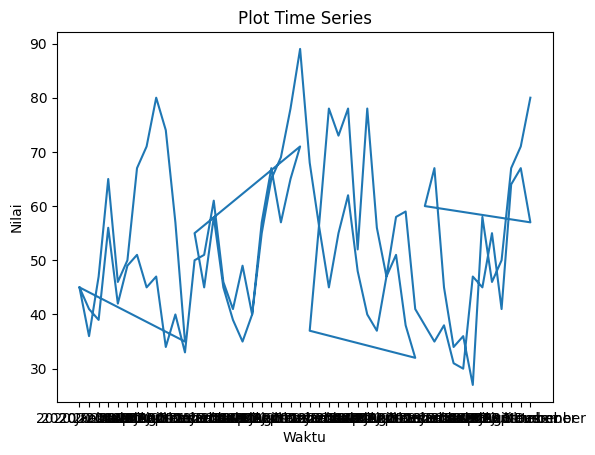

In [5]:
import matplotlib.pyplot as plt

# Visualisasi data time series
plt.plot(data['tahun_bulan'], data['jumlah_pengunjung'])
plt.title('Plot Time Series')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

dari visualisasi data di atas terlihat masih memiliki banyak outlier maka say akan melakukan penghapusan outlier

### mengidentifikasi dan menghapus outlier

In [6]:
from scipy.stats import zscore

# Menghitung Z-Score
data_filtered['z_score'] = zscore(data_filtered['jumlah_pengunjung'])

# Menghapus outlier jika Z-Score lebih dari 3 atau kurang dari -3
data_filtered_cleaned = data_filtered[data_filtered['z_score'].abs() <= 3]


<ipython-input-6-f2ad66d24551>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['z_score'] = zscore(data_filtered['jumlah_pengunjung'])


kode di atas digunakan untuk mengidentifikasi dan menghapus outlier dari dataset berdasarkan nilai Z-Score, dengan asumsi bahwa nilai data yang memiliki Z-Score lebih dari 3 atau kurang dari -3 adalah outlier. Proses ini membantu membersihkan data agar model yang dilatih tidak dipengaruhi oleh nilai-nilai ekstrem yang dapat mengganggu hasil analisis atau prediksi.

### Melakukan LOESS smoothing

LOESS smoothing (Local Regression Smoothing) adalah metode untuk memperhalus data yang berfluktuasi atau bergelombang, dengan tujuan untuk mendapatkan tren atau pola yang lebih jelas, menghilangkan kebisingan (noise), dan menyajikan data dalam bentuk yang lebih mudah dianalisis atau diprediksi.

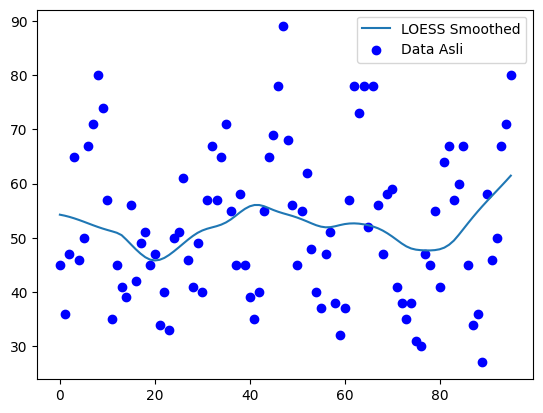

In [7]:
from statsmodels.nonparametric.smoothers_lowess import lowess

smoothed = lowess(data_filtered_cleaned['jumlah_pengunjung'], data_filtered_cleaned.index, frac=0.3)

# Plot data smoothed
plt.plot(smoothed[:, 0], smoothed[:, 1], label='LOESS Smoothed')
plt.scatter(data_filtered_cleaned.index, data_filtered_cleaned['jumlah_pengunjung'], color='blue', label='Data Asli')
plt.legend()
plt.show()


### visualisasi data setelah di hapus outliernya

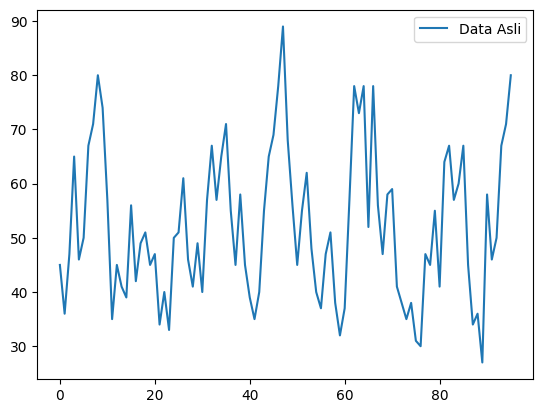

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Model ARIMA
model = ARIMA(data_filtered_cleaned['jumlah_pengunjung'], order=(5,1,0))  # Sesuaikan dengan data Anda
model_fit = model.fit()

# Prediksi untuk 12 periode ke depan
forecast = model_fit.forecast(steps=12)

# Plot hasil tanpa prediksi
plt.plot(data_filtered_cleaned.index, data_filtered_cleaned['jumlah_pengunjung'], label='Data Asli')
plt.legend()
plt.show()


Mengambil kolom nilai jumlah_pengunjungdalam bentuk array numpy untuk digunakan dalam analisis.

In [9]:
prices = data['jumlah_pengunjung'].values
print(prices)

[45 36 47 65 46 50 67 71 80 74 57 35 45 41 39 56 42 49 51 45 47 34 40 33
 50 51 61 46 41 49 40 57 67 57 65 71 55 45 58 45 39 35 40 55 65 69 78 89
 68 56 45 55 62 48 40 37 47 51 38 32 37 57 78 73 78 52 78 56 47 58 59 41
 38 35 38 31 30 47 45 55 41 64 67 57 60 67 45 34 36 27 58 46 50 67 71 80]


### melakukan sliding window

In [10]:
import numpy as np # Import numpy library and give it alias 'np'

def sliding_window(data_filtered_cleaned, window_size):
    X, y = [], []
    for i in range(len(data_filtered_cleaned) - window_size):
        X.append(data_filtered_cleaned[i:i + window_size])
        y.append(data_filtered_cleaned[i + window_size])
    return np.array(X), np.array(y)

window_size = 3  # Ukuran jendela =3
X, y = sliding_window(prices, window_size)
print("X:", X)
print("y:", y)

X: [[45 36 47]
 [36 47 65]
 [47 65 46]
 [65 46 50]
 [46 50 67]
 [50 67 71]
 [67 71 80]
 [71 80 74]
 [80 74 57]
 [74 57 35]
 [57 35 45]
 [35 45 41]
 [45 41 39]
 [41 39 56]
 [39 56 42]
 [56 42 49]
 [42 49 51]
 [49 51 45]
 [51 45 47]
 [45 47 34]
 [47 34 40]
 [34 40 33]
 [40 33 50]
 [33 50 51]
 [50 51 61]
 [51 61 46]
 [61 46 41]
 [46 41 49]
 [41 49 40]
 [49 40 57]
 [40 57 67]
 [57 67 57]
 [67 57 65]
 [57 65 71]
 [65 71 55]
 [71 55 45]
 [55 45 58]
 [45 58 45]
 [58 45 39]
 [45 39 35]
 [39 35 40]
 [35 40 55]
 [40 55 65]
 [55 65 69]
 [65 69 78]
 [69 78 89]
 [78 89 68]
 [89 68 56]
 [68 56 45]
 [56 45 55]
 [45 55 62]
 [55 62 48]
 [62 48 40]
 [48 40 37]
 [40 37 47]
 [37 47 51]
 [47 51 38]
 [51 38 32]
 [38 32 37]
 [32 37 57]
 [37 57 78]
 [57 78 73]
 [78 73 78]
 [73 78 52]
 [78 52 78]
 [52 78 56]
 [78 56 47]
 [56 47 58]
 [47 58 59]
 [58 59 41]
 [59 41 38]
 [41 38 35]
 [38 35 38]
 [35 38 31]
 [38 31 30]
 [31 30 47]
 [30 47 45]
 [47 45 55]
 [45 55 41]
 [55 41 64]
 [41 64 67]
 [64 67 57]
 [67 57 60]
 

In [11]:
jumlahData=len(X)
print(jumlahData)

93


### Normalisasikan data

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi data X
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
!pip install scikit-learn

### Membagi data menjadi set latih dan uji

In [14]:
from sklearn.model_selection import train_test_split # Import the train_test_split function

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [15]:
print(y_train)

[47 51 41 64 57 55 39 58 38 65 41 45 35 80 69 45 45 68 45 57 57 40 40 55
 41 47 42 46 67 47 35 35 30 74 50 45 58 32 80 51 78 48 45 56 56 78 71 34
 65 57 55 60 37 71 46 78 78 67 39 67 46 37 50 50 61 36 47 27 67 33 73 38
 49 40]


## Modelling

### Melatih model BaggingRegressor

In [16]:
#membuat model dengan decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

tree = DecisionTreeRegressor()
bagging_model2 = BaggingRegressor(estimator=tree, n_estimators=10, random_state=42)

# Melatih model pada data
bagging_model2.fit(X_train, y_train)


BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)

## Evaluasi

In [17]:
from sklearn.metrics import mean_squared_error

y_pred2 = bagging_model2.predict(X_test)

# Prediksi pada data training untuk menghitung RMSE
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print("RMSE:", rmse2)

# Menghitung MAPE
mape2 = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100
print("MAPE:", mape2)


RMSE: 11.843141475132347
MAPE: 20.746369614266555


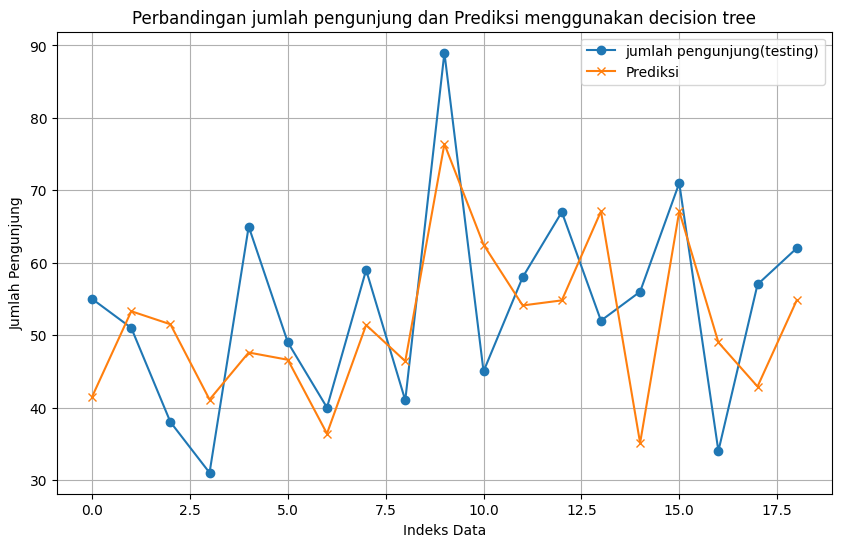

In [18]:
# 6. Visualisasi Hasil (Opsional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label='jumlah pengunjung(testing)', marker='o')
plt.plot(range(len(y_pred2)), y_pred2, label='Prediksi', marker='x')
plt.xlabel('Indeks Data')
plt.ylabel('Jumlah Pengunjung')
plt.title('Perbandingan jumlah pengunjung dan Prediksi menggunakan decision tree')
plt.legend()
plt.grid(True)
plt.show()

### melakukan uji coba pada model yang di latih untuk melakukan prediksi

In [19]:
new_data = np.array([prices[-3:]])  # Mengambil 3 hari terakhir

# Prediksi harga pada minggu ke-41
predicted_price2 = bagging_model2.predict(new_data)
print("hasil prediksi jumlah pengunjung:", predicted_price2)

hasil prediksi jumlah pengunjung: [76.4]


In [20]:
import pickle # Import the pickle module

with open('bagging_model2.pkl', 'wb') as file:
    pickle.dump(bagging_model2, file)
print("Model berhasil disimpan sebagai 'bagging_model2.pkl'.")

Model berhasil disimpan sebagai 'bagging_model2.pkl'.


## Hasil Deploy

ini adalah hasil deploy untuk prediksi ini :
https://huggingface.co/spaces/yudhanuurcahyo/psd_prediksi_tugas1
